In [ ]:
import os
import json
import shutil
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/cardamom_grade_dataset.zip"

WORK_DIR = Path("/content/cardamom_grading")
RAW_DIR = WORK_DIR / "raw"

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

RAW_DIR.mkdir(parents=True, exist_ok=True)

!unzip -q "$ZIP_PATH" -d "$RAW_DIR"

print("Unzipped folders:")
!find "$RAW_DIR" -maxdepth 4 -type d | sort

Mounted at /content/drive
Unzipped folders:
/content/cardamom_grading/raw
/content/cardamom_grading/raw/dataset
/content/cardamom_grading/raw/dataset/test
/content/cardamom_grading/raw/dataset/test/Cardmom Grade A
/content/cardamom_grading/raw/dataset/test/Cardmom Grade B
/content/cardamom_grading/raw/dataset/test/Cardmom Grade C
/content/cardamom_grading/raw/dataset/train
/content/cardamom_grading/raw/dataset/train/Cardmom Grade A
/content/cardamom_grading/raw/dataset/train/Cardmom Grade B
/content/cardamom_grading/raw/dataset/train/Cardmom Grade C
/content/cardamom_grading/raw/dataset/validation
/content/cardamom_grading/raw/dataset/validation/Cardmom Grade A
/content/cardamom_grading/raw/dataset/validation/Cardmom Grade B
/content/cardamom_grading/raw/dataset/validation/Cardmom Grade C


In [ ]:
candidates = []

for p in RAW_DIR.rglob("*"):
    if (p / "train").is_dir() and (p / "validation").is_dir() and (p / "test").is_dir():
        candidates.append(p)

if not candidates:
    raise Exception("Could not find dataset root. Make sure zip contains train, validation, and test folders.")

DATASET_ROOT = candidates[0]
print("Dataset root:", DATASET_ROOT)

for split in ["train", "validation", "test"]:
    print("\n", split.upper())
    split_path = DATASET_ROOT / split
    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            count = len([f for f in class_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]])
            print(class_dir.name, ":", count)

Dataset root: /content/cardamom_grading/raw/dataset

 TRAIN
Cardmom Grade A : 627
Cardmom Grade B : 588
Cardmom Grade C : 807

 VALIDATION
Cardmom Grade A : 134
Cardmom Grade B : 126
Cardmom Grade C : 173

 TEST
Cardmom Grade A : 135
Cardmom Grade B : 126
Cardmom Grade C : 174


In [ ]:
def crop_pod_to_square(img_bgr, debug=False):
    """
    Detects the pod from white/gray background, crops it with padding,
    and places it on a square white canvas.
    Returns cropped BGR image or None if pod is not detected.
    """

    if img_bgr is None:
        return None

    h_img, w_img = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Pod has more saturation/darker pixels than white/gray background.
    mask = ((s > 25) & (v < 245)).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)

    min_area = max(200, h_img * w_img * 0.0002)

    if area < min_area:
        return None

    x, y, w, h = cv2.boundingRect(contour)

    pad = int(max(w, h) * 0.8) + 20

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w_img, x + w + pad)
    y2 = min(h_img, y + h + pad)

    crop = img_bgr[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    ch, cw = crop.shape[:2]
    side = max(ch, cw)

    canvas = np.ones((side, side, 3), dtype=np.uint8) * 255

    y_offset = (side - ch) // 2
    x_offset = (side - cw) // 2

    canvas[y_offset:y_offset + ch, x_offset:x_offset + cw] = crop

    return canvas

In [ ]:
CROPPED_ROOT = WORK_DIR / "dataset_cropped"

if CROPPED_ROOT.exists():
    shutil.rmtree(CROPPED_ROOT)

image_exts = [".jpg", ".jpeg", ".png", ".webp"]

failed_images = []

for split in ["train", "validation", "test"]:
    split_input = DATASET_ROOT / split
    split_output = CROPPED_ROOT / split

    for class_dir in sorted(split_input.iterdir()):
        if not class_dir.is_dir():
            continue

        out_class_dir = split_output / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() not in image_exts:
                continue

            img_bgr = cv2.imread(str(img_path))
            cropped = crop_pod_to_square(img_bgr)

            if cropped is None:
                failed_images.append(str(img_path))
                cropped = img_bgr

            out_path = out_class_dir / img_path.name
            cv2.imwrite(str(out_path), cropped)

print("Cropped dataset created:", CROPPED_ROOT)
print("Failed crop count:", len(failed_images))

for split in ["train", "validation", "test"]:
    print("\n", split.upper())
    for class_dir in sorted((CROPPED_ROOT / split).iterdir()):
        if class_dir.is_dir():
            count = len([f for f in class_dir.iterdir() if f.suffix.lower() in image_exts])
            print(class_dir.name, ":", count)

Cropped dataset created: /content/cardamom_grading/dataset_cropped
Failed crop count: 0

 TRAIN
Cardmom Grade A : 627
Cardmom Grade B : 588
Cardmom Grade C : 807

 VALIDATION
Cardmom Grade A : 134
Cardmom Grade B : 126
Cardmom Grade C : 173

 TEST
Cardmom Grade A : 135
Cardmom Grade B : 126
Cardmom Grade C : 174


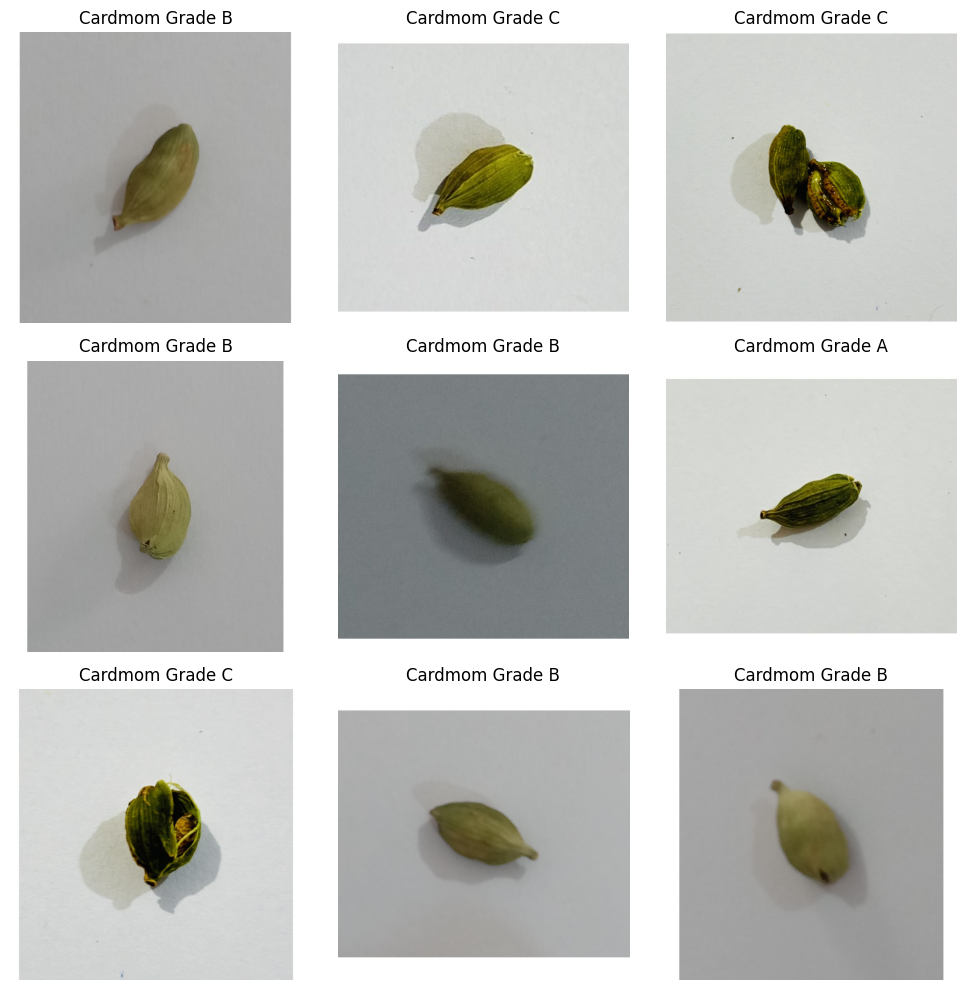

In [ ]:
def show_random_samples(root, split="train", n=9):
    split_path = Path(root) / split
    all_images = []

    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() in image_exts:
                    all_images.append((img_path, class_dir.name))

    samples = random.sample(all_images, min(n, len(all_images)))

    plt.figure(figsize=(10, 10))

    for i, (img_path, label) in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(CROPPED_ROOT, "train", 9)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    CROPPED_ROOT / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    CROPPED_ROOT / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    CROPPED_ROOT / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 2022 files belonging to 3 classes.
Found 433 files belonging to 3 classes.
Found 435 files belonging to 3 classes.
Class names: ['Cardmom Grade A', 'Cardmom Grade B', 'Cardmom Grade C']
Number of classes: 3


In [ ]:
train_counts = Counter()

for class_name in class_names:
    class_path = CROPPED_ROOT / "train" / class_name
    train_counts[class_name] = len([f for f in class_path.iterdir() if f.suffix.lower() in image_exts])

print(train_counts)

total = sum(train_counts.values())

class_weight = {
    i: total / (num_classes * train_counts[class_names[i]])
    for i in range(num_classes)
}

print("Class weights:", class_weight)

Counter({'Cardmom Grade C': 807, 'Cardmom Grade A': 627, 'Cardmom Grade B': 588})
Class weights: {0: 1.0749601275917064, 1: 1.1462585034013606, 2: 0.8351920693928129}


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.20),
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
BEST_MODEL_PATH = "/content/best_cardamom_grade.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5219 - loss: 1.1469
Epoch 1: val_accuracy improved from None to 0.79908, saving model to /content/best_cardamom_grade.keras

Epoch 1: finished saving model to /content/best_cardamom_grade.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 217ms/step - accuracy: 0.6424 - loss: 0.8467 - val_accuracy: 0.7991 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 2/30
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7753 - loss: 0.5252
Epoch 2: val_accuracy improved from 0.79908 to 0.83834, saving model to /content/best_cardamom_grade.keras

Epoch 2: finished saving model to /content/best_cardamom_grade.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.8017 - loss: 0.4800 - val_accuracy: 0.8383 - val_loss: 0.4729 - learning_rate: 0.0010
Epoch 3/30
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8017 - loss: 0.4734
Epoch 3: val_accuracy did not improve from 0.83834
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.

In [ ]:
base_model.trainable = True

# Freeze most layers, fine-tune only last part
for layer in base_model.layers[:-35]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7593 - loss: 0.6346
Epoch 1: val_accuracy improved from 0.88684 to 0.88915, saving model to /content/best_cardamom_grade.keras

Epoch 1: finished saving model to /content/best_cardamom_grade.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 219ms/step - accuracy: 0.7972 - loss: 0.5230 - val_accuracy: 0.8891 - val_loss: 0.3066 - learning_rate: 1.0000e-05
Epoch 2/25
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8549 - loss: 0.3698
Epoch 2: val_accuracy did not improve from 0.88915
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 197ms/step - accuracy: 0.8709 - loss: 0.3330 - val_accuracy: 0.8891 - val_loss: 0.3268 - learning_rate: 1.0000e-05
Epoch 3/25
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8766 - loss: 0.3034
Epoch 3: val_accuracy did not improve from 0.88915
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.8932 - loss: 0.2702 - val_accuracy: 0.8476 - val_loss: 0.3843 - learning_rate: 1.0000e-05
Epoch 4/25
63/64 ━━━━━━━━

In [ ]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step - accuracy: 0.9264 - loss: 0.2305
Test accuracy: 0.9264367818832397
Test loss: 0.23047104477882385


                 precision    recall  f1-score   support

Cardmom Grade A       0.86      0.95      0.90       135
Cardmom Grade B       0.95      1.00      0.98       126
Cardmom Grade C       0.97      0.86      0.91       174

       accuracy                           0.93       435
      macro avg       0.93      0.93      0.93       435
   weighted avg       0.93      0.93      0.93       435



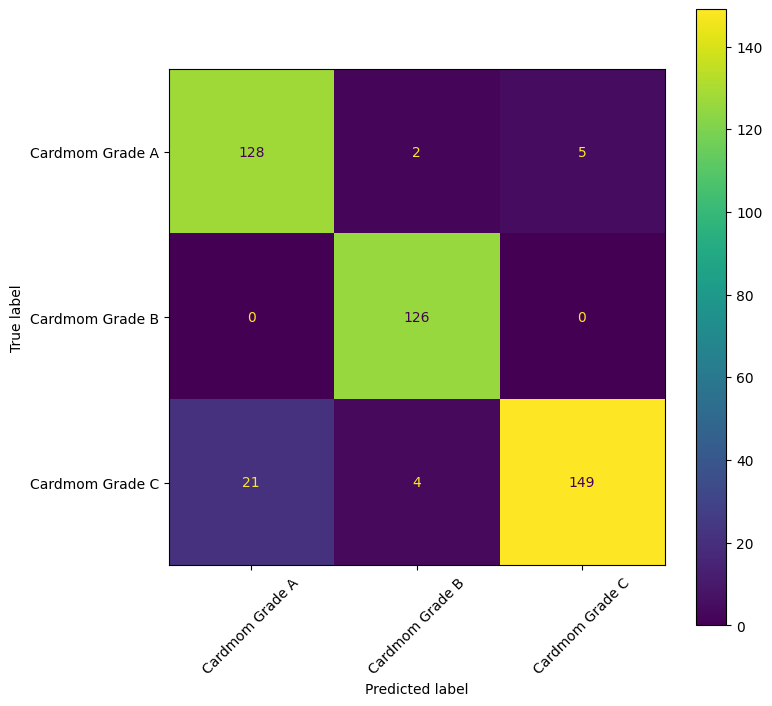

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

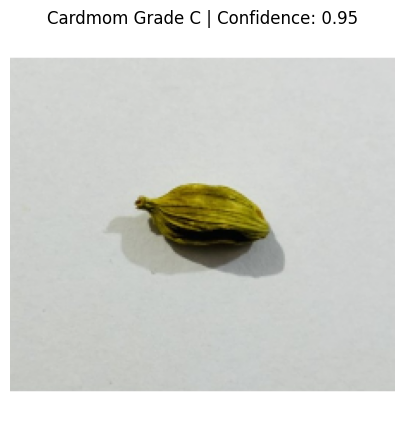

{'grade': 'Cardmom Grade C',
 'confidence': 0.9527695178985596,
 'all_probabilities': {'Cardmom Grade A': 0.042900726199150085,
  'Cardmom Grade B': 0.004329783376306295,
  'Cardmom Grade C': 0.9527695178985596}}

In [ ]:
def predict_single_image(image_path, model, threshold=0.70):
    img_bgr = cv2.imread(str(image_path))

    if img_bgr is None:
        return {
            "status": "error",
            "message": "Image not found or cannot read image."
        }

    cropped = crop_pod_to_square(img_bgr)

    if cropped is None:
        return {
            "status": "invalid",
            "message": "No clear cardamom pod detected. Please capture again with clear background."
        }

    img_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, IMG_SIZE)

    input_arr = np.expand_dims(resized.astype(np.float32), axis=0)

    probs = model.predict(input_arr, verbose=0)[0]
    pred_index = int(np.argmax(probs))
    confidence = float(probs[pred_index])

    if confidence < threshold:
        result = "Uncertain"
    else:
        result = class_names[pred_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(resized.astype(np.uint8))
    plt.title(f"{result} | Confidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    return {
        "grade": result,
        "confidence": confidence,
        "all_probabilities": {
            class_names[i]: float(probs[i]) for i in range(len(class_names))
        }
    }

# Example: change this path to any image from test folder
sample_image = list((CROPPED_ROOT / "test").rglob("*.jpg"))[0]
predict_single_image(sample_image, best_model)

Saving 2026_05_03_10_42_IMG_8080.jpg to 2026_05_03_10_42_IMG_8080.jpg

Testing image: 2026_05_03_10_42_IMG_8080.jpg


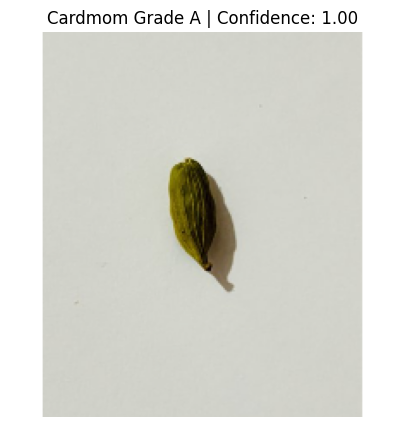


Prediction Result:
Predicted Grade: Cardmom Grade A
Confidence: 99.67%

All Class Probabilities:
Cardmom Grade A: 99.67%
Cardmom Grade B: 0.10%
Cardmom Grade C: 0.23%


In [ ]:
from google.colab import files
import os

# Upload image
uploaded = files.upload()

# Get uploaded image path
for filename in uploaded.keys():
    print(f"\nTesting image: {filename}")

    result = predict_single_image(
        filename,
        best_model,
        threshold=0.70
    )

    print("\nPrediction Result:")

    if result.get("status") == "error":
        print("Error:", result["message"])

    elif result.get("status") == "invalid":
        print("Invalid image:", result["message"])

    else:
        print("Predicted Grade:", result["grade"])
        print(f"Confidence: {result['confidence'] * 100:.2f}%")

        print("\nAll Class Probabilities:")
        for class_name, probability in result["all_probabilities"].items():
            print(f"{class_name}: {probability * 100:.2f}%")

In [ ]:
CLASS_NAMES_PATH = "/content/class_names.json"

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f, indent=2)

print("Saved:", CLASS_NAMES_PATH)
print(class_names)

Saved: /content/class_names.json
['Cardmom Grade A', 'Cardmom Grade B', 'Cardmom Grade C']


In [ ]:
SAVED_MODEL_DIR = "/content/cardamom_grade_saved_model"

if os.path.exists(SAVED_MODEL_DIR):
    shutil.rmtree(SAVED_MODEL_DIR)

best_model.export(SAVED_MODEL_DIR)

print("SavedModel exported to:", SAVED_MODEL_DIR)

Saved artifact at '/content/cardamom_grade_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134897409240976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134897409239248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134897552462224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134897552461648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643444624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643452112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643452880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643452688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643451920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134895643453456: TensorSpec(shape=(), dtype=tf.resource, name=No

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)

# Good basic optimization for mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

TFLITE_PATH = "/content/cardamom_grade_model.tflite"

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved:", TFLITE_PATH)
print("TFLite model size MB:", os.path.getsize(TFLITE_PATH) / (1024 * 1024))

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/data_augmentation_1/random_brightness_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___51860"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___52939"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.StatelessRandomGetKeyCounter' op is neither a custom op nor a flex op
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___52939"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/data_augmentation_1/random_brightness_1/stateless_random_uniform/S

In [ ]:
from google.colab import files

files.download(BEST_MODEL_PATH)
#files.download(TFLITE_PATH)
files.download(CLASS_NAMES_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>